In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score, precision_recall_curve

from sklearn.metrics import PrecisionRecallDisplay
from collections import Counter


import warnings
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# read in data
az = pd.read_csv('data/azimuth_hlca.csv', index_col=0)
ct = pd.read_csv('data/celltypist_hlca.csv', index_col=0)
sc = pd.read_csv('data/scarches_hlca.csv', index_col=0)
fr = pd.read_csv('data/frmatch_hlca.csv', index_col=0)
sr = pd.read_csv('data/singleR_hlca.csv', index_col=0)
srr = pd.read_csv('data/singleR_hlca_refined.csv', index_col=0)
sp = pd.read_csv('data/scpred_hlca.csv', index_col=0)

# Validation Metrics

In [17]:
def overall_metrics(df): 
    # overall metrics
    warnings.filterwarnings('ignore')
    true_labels = df.loc[:,'hlca_true'].to_list()
    predicted_labels = df.loc[:,'hlca_pred'].to_list()

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')  
    recall = recall_score(true_labels, predicted_labels, average='weighted')  
    f1 = f1_score(true_labels, predicted_labels, average='weighted') 
    
    return [accuracy, precision, recall, f1]

In [18]:
az_metrics = overall_metrics(az)
ct_metrics = overall_metrics(ct)
fr_metrics = overall_metrics(fr)
sc_metrics = overall_metrics(sc)
sr_metrics = overall_metrics(sr)
srr_metrics = overall_metrics(srr)
sp_metrics = overall_metrics(sp)

## By Metric

In [19]:
metrics = ("precision", "recall", "f1")

az_metrics = overall_metrics(az)
ct_metrics = overall_metrics(ct)
fr_metrics = overall_metrics(fr)
sc_metrics = overall_metrics(sc)
sr_metrics = overall_metrics(sr)
srr_metrics = overall_metrics(srr)
sp_metrics = overall_metrics(sp)

acc = [ sp_metrics[0], sr_metrics[0], srr_metrics[0], az_metrics[0], ct_metrics[0], sc_metrics[0], fr_metrics[0], ]
prec = [ sp_metrics[1], sr_metrics[1], srr_metrics[1], az_metrics[1], ct_metrics[1], sc_metrics[1], fr_metrics[1], ]
rec = [ sp_metrics[2], sr_metrics[2], srr_metrics[2], az_metrics[2], ct_metrics[2], sc_metrics[2], fr_metrics[2], ]
f1 = [ sp_metrics[3], sr_metrics[3], srr_metrics[3], az_metrics[3], ct_metrics[3], sc_metrics[3], fr_metrics[3], ]


methods = {
    'scPred': [sp_metrics[1], sp_metrics[2], sp_metrics[3]],
    'singleR': [sr_metrics[1], sr_metrics[2], sr_metrics[3]],
    # 'singleR (refined)': [srr_metrics[1], srr_metrics[2], srr_metrics[3]],
    'Azimuth': [az_metrics[1], az_metrics[2], az_metrics[3]],
    'CellTypist': [ct_metrics[1], ct_metrics[2], ct_metrics[3]],
    'scArches': [sc_metrics[1], sc_metrics[2], sc_metrics[3]],
    'FR-Match': [fr_metrics[1], fr_metrics[2], fr_metrics[3]],
}


methods2 = {
    'scPred': [sp_metrics[1], sp_metrics[2], sp_metrics[3]],
    'singleR': [sr_metrics[1], sr_metrics[2], sr_metrics[3]],
    'singleR (refined)': [srr_metrics[1], srr_metrics[2], srr_metrics[3]],
    'Azimuth': [az_metrics[1], az_metrics[2], az_metrics[3]],
    'CellTypist': [ct_metrics[1], ct_metrics[2], ct_metrics[3]],
    'scArches': [sc_metrics[1], sc_metrics[2], sc_metrics[3]],
    'FR-Match': [fr_metrics[1], fr_metrics[2], fr_metrics[3]],
}

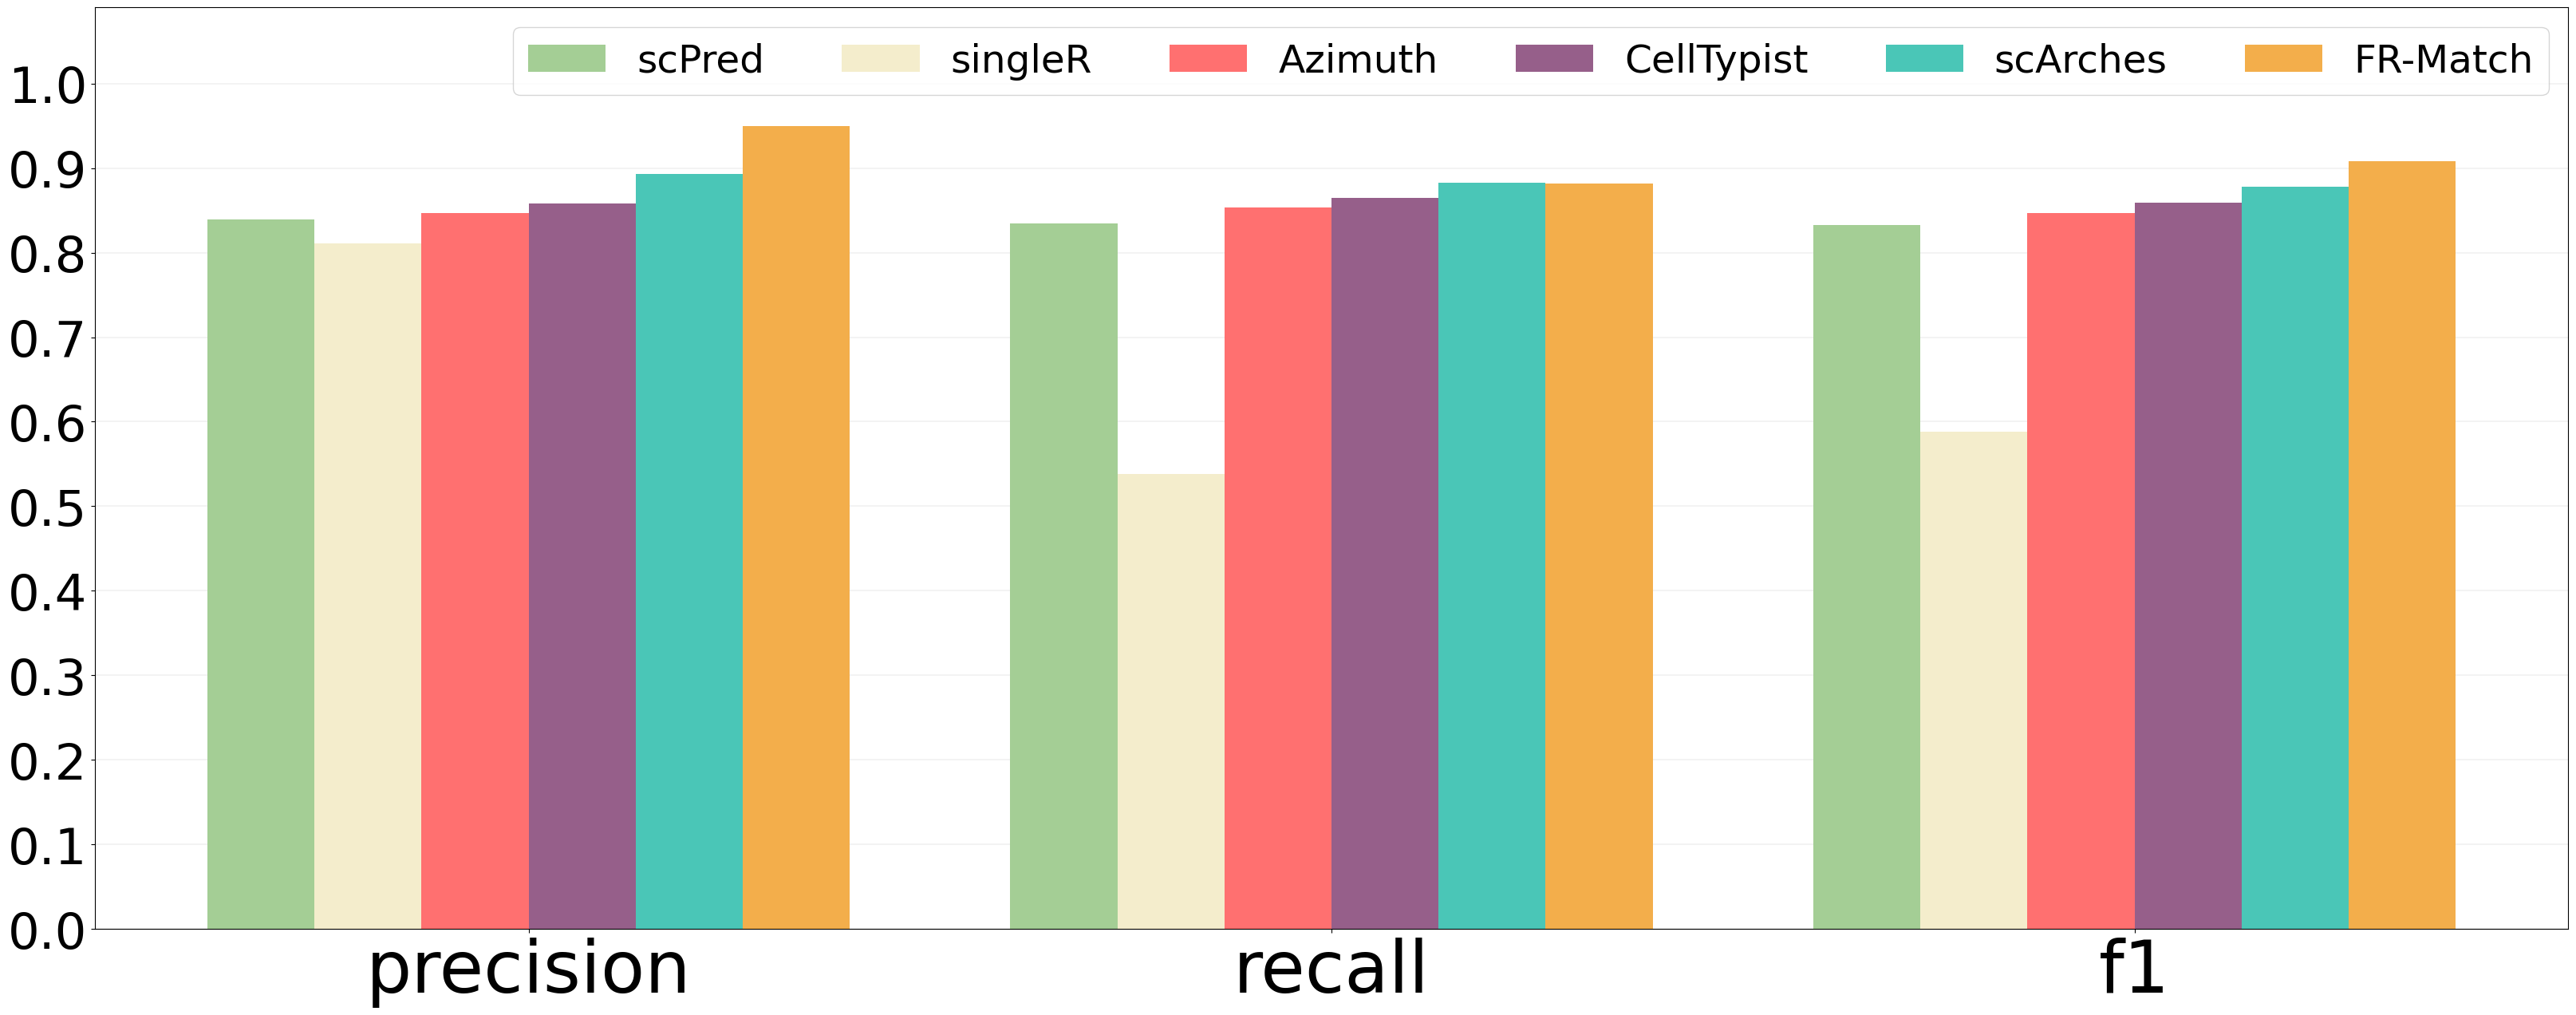

In [20]:
spacing = 1.5
x = np.arange(len(metrics)) * spacing  # the label locations
width = 0.2  # the width of the bars
multiplier = 0
#colors = ['#5F5D9C', '#6196A6', '#A4CE95','#F4EDCC'] #'#5F5D9C', '#F4EDCC'
#colors = ['#e7298a', '#d95f02', '#1b9e77', '#7570b3']
colors = ['#A4CE95', '#F4EDCC', '#FF7070', '#965F8A', '#4AC6B7', '#F3AE4B', ]

fig, ax = plt.subplots(figsize=(40, 15))
    
for attribute, measurement in methods.items():
    offset = width * multiplier
    rects = ax.bar(x + offset - width * ((len(methods) -1 ) / 2), measurement, width, label=attribute, color=colors[multiplier], zorder=2)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_ylabel('Precision, Recall, F1 Metrics', fontsize=30, labelpad=20)
#ax.set_xlabel('61 Cell Types in HLCA', fontsize=25, labelpad=20)
#ax.set_title('HLCA Overall Validation Metrics', fontsize=35)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=65)
ax.tick_params(axis='y', labelsize=45)

ax.legend(loc='upper right', ncols=7, fontsize=35)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_ylim(0, 1.09)

# add lines behind the plot
ax.yaxis.grid(True, linestyle='-', linewidth=0.2, zorder=1)


plt.show()

In [21]:
# spacing = 1.5
# x = np.arange(len(metrics)) * spacing  # the label locations
# width = 0.18  # the width of the bars
# multiplier = 0
# #colors = ['#5F5D9C', '#6196A6', '#A4CE95','#F4EDCC'] #'#5F5D9C', '#F4EDCC'
# #colors = ['#e7298a', '#d95f02', '#1b9e77', '#7570b3']
# colors = ['#A4CE95', '#F4EDCC', '#5F5D9C', '#FF7070', '#965F8A', '#4AC6B7', '#F3AE4B', ]

# fig, ax = plt.subplots(figsize=(40, 15))
    
# for attribute, measurement in methods2.items():
#     offset = width * multiplier
#     rects = ax.bar(x + offset - width * ((len(methods) -1 ) / 2), measurement, width, label=attribute, color=colors[multiplier], zorder=2)
#     #ax.bar_label(rects, padding=3)
#     multiplier += 1

# # Add some text for labels, title and custom x-axis tick labels, etc.
# # ax.set_ylabel('Precision, Recall, F1 Metrics', fontsize=30, labelpad=20)
# #ax.set_xlabel('61 Cell Types in HLCA', fontsize=25, labelpad=20)
# #ax.set_title('HLCA Overall Validation Metrics', fontsize=35)

# ax.set_xticks(x)
# ax.set_xticklabels(metrics, fontsize=65)
# ax.tick_params(axis='y', labelsize=45)

# ax.legend(loc='upper right', ncols=7, fontsize=33)
# ax.set_yticks(np.arange(0, 1.1, 0.1))
# ax.set_ylim(0, 1.05)

# # add lines behind the plot
# ax.yaxis.grid(True, linestyle='-', linewidth=0.2, zorder=1)


# plt.show()

# Boxplots

In [22]:
def get_metrics(df):
    # metrics by cell type
    
    a_lst = []
    p_lst = []
    r_lst = []
    f1_lst = []
    type_lst = []
    
    for cell_type in df['hlca_true'].unique():
        # subset by cell type
        subset = df[(df['hlca_true'] == cell_type) | (df['hlca_pred'] == cell_type)]

        # get metrics
        true_labels = subset.loc[:,'hlca_true'].to_list()
        predicted_labels = subset.loc[:,'hlca_pred'].to_list()
        
        # binarize 
        true_labels = np.array(true_labels)  
        true_labels = (true_labels == cell_type).astype(int)
        
        predicted_labels = np.array(predicted_labels)  
        predicted_labels = (predicted_labels == cell_type).astype(int)
        

        accuracy = accuracy_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels)  
        recall = recall_score(true_labels, predicted_labels)  
        f1 = f1_score(true_labels, predicted_labels) 

        a_lst.append(accuracy)
        p_lst.append(precision)
        r_lst.append(recall)
        f1_lst.append(f1)
        type_lst.append(cell_type)

    data = {
        'original_label': type_lst, 
        'accuracy': a_lst,
        'precision': p_lst,
        'recall': r_lst,
        'f1': f1_lst
    }
    metrics_df = pd.DataFrame(data)
    return metrics_df
    

In [23]:
az_cluster_metrics = get_metrics(az)
ct_cluster_metrics = get_metrics(ct)
fr_cluster_metrics = get_metrics(fr)
sc_cluster_metrics = get_metrics(sc)
sr_cluster_metrics = get_metrics(sr)
srr_cluster_metrics = get_metrics(srr)
sp_cluster_metrics = get_metrics(sp)

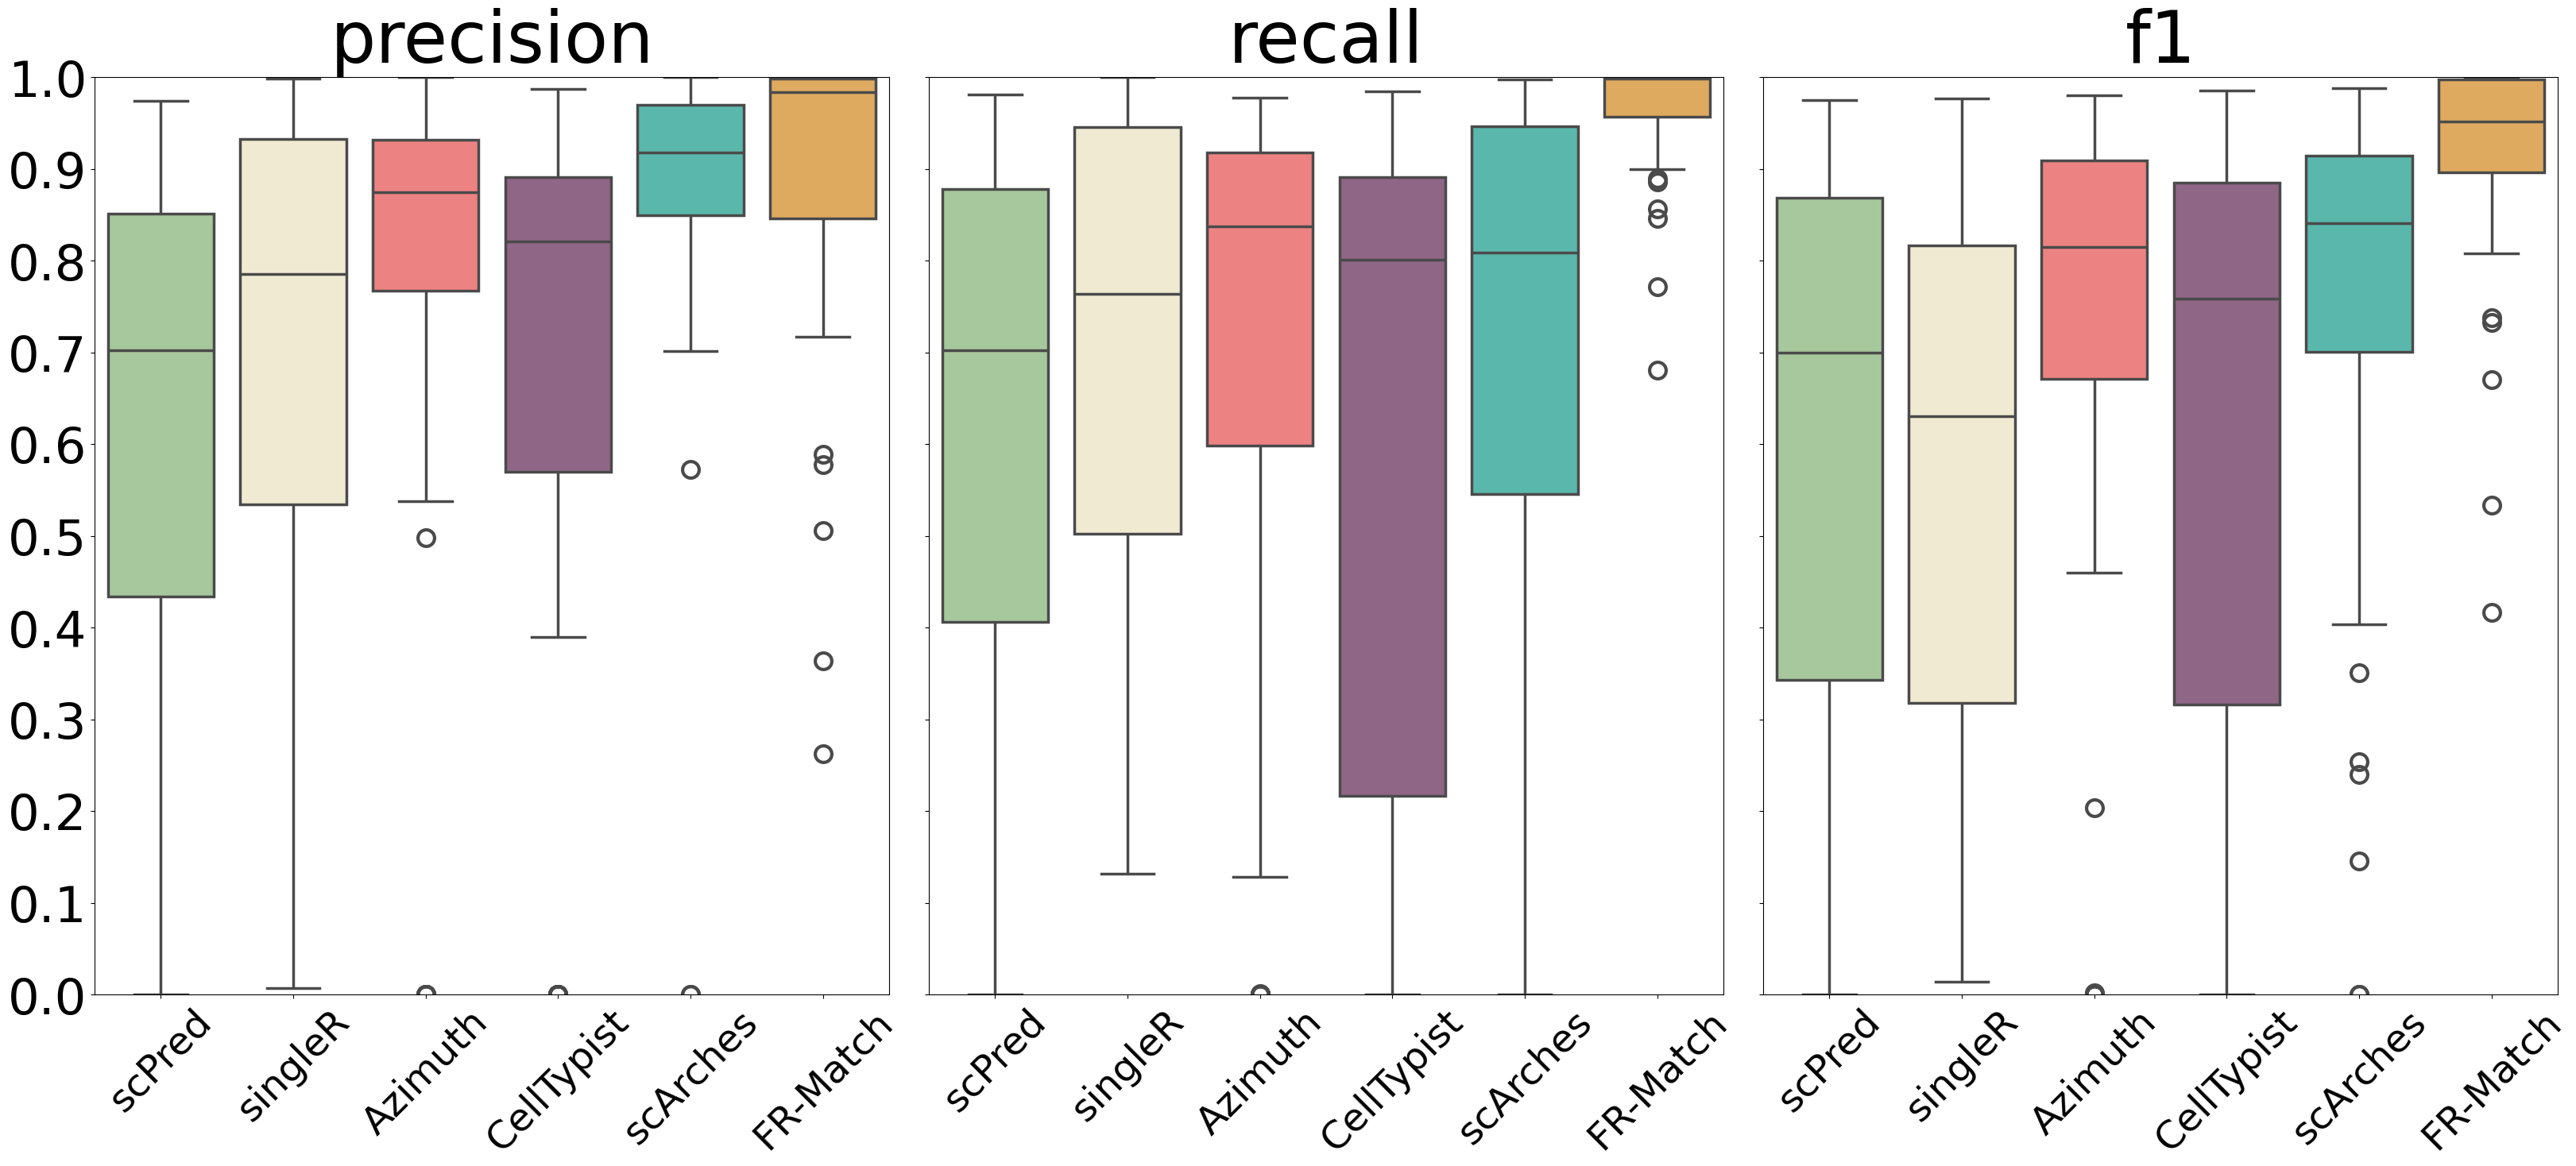

In [24]:
metrics = ['precision', 'recall', 'f1']
colors = ['#A4CE95', '#F4EDCC', '#FF7070', '#965F8A', '#4AC6B7', '#F3AE4B', ] #['#5F5D9C', '#6196A6', '#A4CE95','#F4EDCC']


def metric_df(metric): 
    data = [sr_cluster_metrics, az_cluster_metrics, ct_cluster_metrics, sc_cluster_metrics, fr_cluster_metrics, ]
    names = ['singleR', 'Azimuth', 'CellTypist', 'scArches', 'FR-Match', ]
    
    # put azimuth into df first
    df = sp_cluster_metrics[metric].to_frame()
    #print(df)
    df['category'] = 'scPred'
    
    # do ct and sc
    for i in range(len(data)): 
        sub = data[i][metric].to_frame()
        sub['category'] = f"{names[i]}"
        df = pd.concat([df, sub])
    return df 

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 15), sharey=True)
for i in range(len(metrics)):
    # get data
    df = metric_df(metrics[i])
    flierprops = dict(marker='.', markersize=30, linestyle='none', markeredgewidth=3)

    # plot
    sns.boxplot(y=metrics[i], x='category', data=df, ax=axes[i], palette=colors, flierprops=flierprops,linewidth=2.5)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_title(f'{metrics[i]}', fontsize=65)
    axes[i].set_ylim(0, 1)  # Set y-axis limits
    axes[i].set_yticks(np.linspace(0, 1, 11))
    axes[i].tick_params(axis='y', labelsize=45)
    axes[i].tick_params(axis='x', labelsize=35, labelrotation=45)


plt.subplots_adjust(wspace=0.05)

In [25]:
# metrics = ['precision', 'recall', 'f1']
# colors = ['#A4CE95', '#F4EDCC', '#5F5D9C', '#FF7070', '#965F8A', '#4AC6B7', '#F3AE4B', ] #['#5F5D9C', '#6196A6', '#A4CE95','#F4EDCC']


# def metric_df(metric): 
#     data = [sr_cluster_metrics, srr_cluster_metrics, az_cluster_metrics, ct_cluster_metrics, sc_cluster_metrics, fr_cluster_metrics, ]
#     names = ['singleR', 'singleR \n (refined)', 'Azimuth', 'CellTypist', 'scArches', 'FR-Match', ]
    
#     # put azimuth into df first
#     df = sp_cluster_metrics[metric].to_frame()
#     #print(df)
#     df['category'] = 'scPred'
    
#     # do ct and sc
#     for i in range(len(data)): 
#         sub = data[i][metric].to_frame()
#         sub['category'] = f"{names[i]}"
#         df = pd.concat([df, sub])
#     return df 

# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 15), sharey=True)
# for i in range(len(metrics)):
#     # get data
#     df = metric_df(metrics[i])
#     flierprops = dict(marker='.', markersize=30, linestyle='none', markeredgewidth=3)

#     # plot
#     sns.boxplot(y=metrics[i], x='category', data=df, ax=axes[i], palette=colors, flierprops=flierprops,linewidth=2.5)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel('')
#     axes[i].set_title(f'{metrics[i]}', fontsize=65)
#     axes[i].set_ylim(0, 1)  # Set y-axis limits
#     axes[i].set_yticks(np.linspace(0, 1, 11))
#     axes[i].tick_params(axis='y', labelsize=45)
#     axes[i].tick_params(axis='x', labelsize=35, labelrotation=45)


# plt.subplots_adjust(wspace=0.05)

In [26]:
for d in [sp_cluster_metrics, sr_cluster_metrics, srr_cluster_metrics,
          az_cluster_metrics, ct_cluster_metrics, sc_cluster_metrics, fr_cluster_metrics]: 
    print(d.describe())

        accuracy  precision     recall         f1
count  61.000000  61.000000  61.000000  61.000000
mean    0.491336   0.618325   0.625155   0.604329
std     0.287053   0.278079   0.296713   0.291785
min     0.000000   0.000000   0.000000   0.000000
25%     0.206658   0.434211   0.406271   0.342530
50%     0.538494   0.702486   0.702561   0.700027
75%     0.766924   0.850942   0.877854   0.868090
max     0.950563   0.973996   0.981277   0.974655
        accuracy  precision     recall         f1
count  61.000000  61.000000  61.000000  61.000000
mean    0.452390   0.676959   0.705971   0.576130
std     0.263618   0.324826   0.272502   0.265590
min     0.007139   0.007139   0.132055   0.014177
25%     0.189145   0.534175   0.501837   0.318119
50%     0.460114   0.785084   0.763944   0.630244
75%     0.689557   0.932551   0.945652   0.816257
max     0.953586   0.998202   1.000000   0.976242
        accuracy  precision     recall         f1
count  61.000000  61.000000  61.000000  61.000000
